<a href="https://colab.research.google.com/github/JeyasriHariharan/scientific-paper-classification/blob/main/Scientific_Paper_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Install required libraries
!pip install kaggle -q
!pip install transformers -q
!pip install keybert -q
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

print("All libraries installed! ✅")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All libraries installed! ✅


In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import re
import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print("All imports successful! ✅")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All imports successful! ✅


In [ ]:
import os

# Check your drive folder
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'data science', 'nlp_project.csv']


In [3]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/nlp_project.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (56181, 3)

Columns: ['terms', 'titles', 'abstracts']

First 5 rows:


,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())

print("\nSample terms:")
print(df['terms'].head(10))

Missing Values:
terms        0
titles       0
abstracts    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56181 entries, 0 to 56180
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   terms      56181 non-null  object
 1   titles     56181 non-null  object
 2   abstracts  56181 non-null  object
dtypes: object(3)
memory usage: 1.3+ MB
None

Sample terms:
0                        ['cs.LG']
1               ['cs.LG', 'cs.AI']
2    ['cs.LG', 'cs.CR', 'stat.ML']
3               ['cs.LG', 'cs.CR']
4                        ['cs.LG']
5             ['cs.LG', 'stat.ML']
6                        ['cs.LG']
7             ['cs.LG', 'stat.ML']
8                        ['cs.LG']
9               ['cs.LG', 'cs.AI']
Name: terms, dtype: object


In [ ]:
import ast

# Domain mapping dictionary
domain_mapping = {
    'cs.LG': 'Machine Learning',
    'cs.AI': 'Artificial Intelligence',
    'cs.CV': 'Computer Vision',
    'cs.CL': 'Natural Language Processing',
    'cs.CR': 'Cybersecurity',
    'cs.RO': 'Robotics',
    'stat.ML': 'Machine Learning',
    'stat.TH': 'Statistics',
    'stat.AP': 'Statistics',
    'stat.ME': 'Statistics',
    'q-bio': 'Bioinformatics',
    'eess.IV': 'Medical Imaging',
    'eess.SP': 'Medical Imaging',
    'cs.NE': 'Artificial Intelligence',
    'cs.IR': 'Natural Language Processing',
    'cs.DS': 'Data Science',
    'cs.SI': 'Data Science',
    'math.ST': 'Statistics',
    'cs.HC': 'Data Science'
}

# Convert terms string to list
df['terms_list'] = df['terms'].apply(ast.literal_eval)

# Get primary domain (first term)
def get_primary_domain(terms):
    for term in terms:
        for key in domain_mapping:
            if key in term:
                return domain_mapping[key]
    return 'Other'

# Create primary domain label
df['primary_domain'] = df['terms_list'].apply(get_primary_domain)

# Check distribution
print("Domain Distribution:")
print(df['primary_domain'].value_counts())
print(f"\nTotal papers with domain: {len(df[df['primary_domain'] != 'Other'])}")

Domain Distribution:
primary_domain
Computer Vision     30995
Machine Learning    25186
Name: count, dtype: int64

Total papers with domain: 56181


In [ ]:
# Check all unique terms
all_terms = []
for terms in df['terms_list']:
    all_terms.extend(terms)

import collections
term_counts = collections.Counter(all_terms)
print("Top 20 most common terms:")
for term, count in term_counts.most_common(20):
    print(f"{term}: {count}")

Top 20 most common terms:
cs.CV: 33433
cs.LG: 30939
stat.ML: 16570
cs.AI: 8390
eess.IV: 2647
cs.RO: 2054
cs.CL: 1659
cs.GR: 1614
cs.NE: 1378
cs.CR: 739
math.OC: 724
cs.SI: 684
eess.SP: 658
cs.MM: 598
cs.SY: 479
cs.IR: 469
cs.HC: 419
cs.MA: 385
eess.SY: 376
cs.IT: 331


In [ ]:
# Updated domain mapping
domain_mapping = {
    'cs.LG': 'Machine Learning',
    'cs.AI': 'Artificial Intelligence',
    'cs.CV': 'Computer Vision',
    'cs.CL': 'Natural Language Processing',
    'cs.CR': 'Cybersecurity',
    'cs.RO': 'Robotics',
    'cs.GR': 'Computer Vision',
    'cs.NE': 'Artificial Intelligence',
    'cs.IR': 'Natural Language Processing',
    'cs.DS': 'Data Science',
    'cs.SI': 'Data Science',
    'cs.HC': 'Data Science',
    'cs.MM': 'Computer Vision',
    'cs.MA': 'Artificial Intelligence',
    'cs.IT': 'Statistics',
    'cs.SY': 'Data Science',
    'stat.ML': 'Machine Learning',
    'stat.TH': 'Statistics',
    'stat.AP': 'Statistics',
    'stat.ME': 'Statistics',
    'math.OC': 'Mathematics',
    'math.ST': 'Statistics',
    'eess.IV': 'Medical Imaging',
    'eess.SP': 'Medical Imaging',
    'eess.SY': 'Medical Imaging',
    'q-bio': 'Bioinformatics'
}

# Get primary domain using first term
def get_primary_domain(terms):
    for term in terms:
        for key in domain_mapping:
            if key in term:
                return domain_mapping[key]
    return 'Other'

# Apply
df['primary_domain'] = df['terms_list'].apply(get_primary_domain)

# Check distribution
print("Domain Distribution:")
print(df['primary_domain'].value_counts())
print(f"\nUnique domains: {df['primary_domain'].nunique()}")

Domain Distribution:
primary_domain
Computer Vision     30995
Machine Learning    25186
Name: count, dtype: int64

Unique domains: 2


In [ ]:
# Create better labels using ALL terms
# Primary domain stays as is (CV or ML)
# But let's create rich multi-labels!

# Create multi-label columns
all_domains = ['Machine Learning', 'Computer Vision',
               'Artificial Intelligence', 'Natural Language Processing',
               'Cybersecurity', 'Robotics', 'Medical Imaging',
               'Statistics', 'Data Science']

def get_all_domains(terms):
    domains = []
    for term in terms:
        for key, value in domain_mapping.items():
            if key in term and value not in domains:
                domains.append(value)
    return domains

df['all_domains'] = df['terms_list'].apply(get_all_domains)

# Show sample
print("Sample multi-labels:")
for i in range(5):
    print(f"Paper {i}: {df['all_domains'][i]}")

print("\nPrimary Domain Distribution:")
print(df['primary_domain'].value_counts())

Sample multi-labels:
Paper 0: ['Machine Learning']
Paper 1: ['Machine Learning', 'Artificial Intelligence']
Paper 2: ['Machine Learning', 'Cybersecurity']
Paper 3: ['Machine Learning', 'Cybersecurity']
Paper 4: ['Machine Learning']

Primary Domain Distribution:
primary_domain
Computer Vision     30995
Machine Learning    25186
Name: count, dtype: int64


In [ ]:
# ============================================
# STEP 8: DATA PREPROCESSING
# Combining title and abstract into one field
# and cleaning the text data
# ============================================

# Combine title and abstract
df['combined_text'] = df['titles'] + ' ' + df['abstracts']

# Text cleaning function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df['cleaned_text'] = df['combined_text'].apply(clean_text)

# Remove stopwords and lemmatize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenize
    tokens = text.split()
    # Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Apply preprocessing
df['processed_text'] = df['cleaned_text'].apply(preprocess_text)

print("Text Preprocessing Complete! ✅")
print(f"\nOriginal text sample:\n{df['combined_text'][0][:200]}")
print(f"\nCleaned text sample:\n{df['processed_text'][0][:200]}")

KeyboardInterrupt: 

In [ ]:
# ============================================
# STEP 9: EXPLORATORY DATA ANALYSIS (EDA)
# Understanding our dataset through
# visualizations and statistics
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Scientific Papers Dataset',
             fontsize=16, fontweight='bold')

# Plot 1: Primary Domain Distribution
ax1 = axes[0, 0]
domain_counts = df['primary_domain'].value_counts()
ax1.bar(domain_counts.index, domain_counts.values,
        color=['#2196F3', '#4CAF50'])
ax1.set_title('Primary Domain Distribution')
ax1.set_xlabel('Domain')
ax1.set_ylabel('Number of Papers')
for i, v in enumerate(domain_counts.values):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

# Plot 2: Abstract Length Distribution
ax2 = axes[0, 1]
df['abstract_length'] = df['abstracts'].apply(lambda x: len(x.split()))
ax2.hist(df['abstract_length'], bins=50, color='#FF9800', edgecolor='black')
ax2.set_title('Abstract Length Distribution')
ax2.set_xlabel('Number of Words')
ax2.set_ylabel('Frequency')

# Plot 3: Title Length Distribution
ax3 = axes[1, 0]
df['title_length'] = df['titles'].apply(lambda x: len(x.split()))
ax3.hist(df['title_length'], bins=30, color='#9C27B0', edgecolor='black')
ax3.set_title('Title Length Distribution')
ax3.set_xlabel('Number of Words')
ax3.set_ylabel('Frequency')

# Plot 4: Multi-label count distribution
ax4 = axes[1, 1]
df['num_labels'] = df['all_domains'].apply(len)
label_counts = df['num_labels'].value_counts().sort_index()
ax4.bar(label_counts.index, label_counts.values, color='#F44336')
ax4.set_title('Number of Labels per Paper')
ax4.set_xlabel('Number of Labels')
ax4.set_ylabel('Number of Papers')

plt.tight_layout()
plt.show()

print("\nBasic Statistics:")
print(f"Average abstract length: {df['abstract_length'].mean():.0f} words")
print(f"Average title length: {df['title_length'].mean():.0f} words")
print(f"Papers with multiple labels: {len(df[df['num_labels'] > 1])}")

In [ ]:
# ============================================
# STEP 10: WORD CLOUD VISUALIZATION
# Visualizing most common words in each
# research domain
# ============================================

from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds by Research Domain',
             fontsize=16, fontweight='bold')

# Word cloud for Computer Vision papers
cv_text = ' '.join(df[df['primary_domain'] == 'Computer Vision']['processed_text'])
wordcloud_cv = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(cv_text)

axes[0].imshow(wordcloud_cv, interpolation='bilinear')
axes[0].set_title('Computer Vision Papers', fontsize=14)
axes[0].axis('off')

# Word cloud for Machine Learning papers
ml_text = ' '.join(df[df['primary_domain'] == 'Machine Learning']['processed_text'])
wordcloud_ml = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(ml_text)

axes[1].imshow(wordcloud_ml, interpolation='bilinear')
axes[1].set_title('Machine Learning Papers', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print("Word Clouds Generated! ✅")

In [ ]:
# ============================================
# STEP 11: TOP TF-IDF KEYWORDS PER DOMAIN
# Finding most important words
# for each research domain
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 TF-IDF Keywords by Domain',
             fontsize=16, fontweight='bold')

domains = ['Computer Vision', 'Machine Learning']
colors = ['#2196F3', '#4CAF50']

for idx, (domain, color) in enumerate(zip(domains, colors)):
    # Get domain text
    domain_text = df[df['primary_domain'] == domain]['processed_text'].tolist()

    # Apply TF-IDF
    tfidf = TfidfVectorizer(max_features=15, ngram_range=(1,2))
    tfidf.fit(domain_text)

    # Get top keywords
    keywords = tfidf.get_feature_names_out()
    scores = tfidf.idf_

    # Sort by score
    sorted_idx = scores.argsort()
    top_keywords = [keywords[i] for i in sorted_idx[:15]]
    top_scores = [scores[i] for i in sorted_idx[:15]]

    # Plot
    axes[idx].barh(top_keywords, top_scores, color=color)
    axes[idx].set_title(f'{domain} - Top Keywords')
    axes[idx].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()
print("TF-IDF Keywords Visualization Done! ✅")

In [ ]:
# ============================================
# STEP 12: DATA PREPARATION FOR ML MODELS
# Splitting dataset into train and test sets
# and creating TF-IDF features
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['domain_encoded'] = le.fit_transform(df['primary_domain'])

print("Label Encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['domain_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['domain_encoded']
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Create TF-IDF features
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF Feature Matrix Shape: {X_train_tfidf.shape}")
print("Data Preparation Complete! ✅")

In [ ]:
# ============================================
# STEP 13: TRADITIONAL ML MODELS
# Building and comparing:
# 1. Logistic Regression
# 2. Naive Bayes
# 3. Random Forest
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Store results
ml_results = {}

# ---- Model 1: Logistic Regression ----
print("=" * 50)
print("1. LOGISTIC REGRESSION")
print("=" * 50)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)
ml_results['Logistic Regression'] = lr_acc
print(f"Accuracy: {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_pred,
      target_names=le.classes_))

# ---- Model 2: Naive Bayes ----
print("=" * 50)
print("2. NAIVE BAYES")
print("=" * 50)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)
ml_results['Naive Bayes'] = nb_acc
print(f"Accuracy: {nb_acc*100:.2f}%")
print(classification_report(y_test, nb_pred,
      target_names=le.classes_))

# ---- Model 3: Random Forest ----
print("=" * 50)
print("3. RANDOM FOREST")
print("=" * 50)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_pred)
ml_results['Random Forest'] = rf_acc
print(f"Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, rf_pred,
      target_names=le.classes_))

print("\n" + "=" * 50)
print("ML MODELS SUMMARY:")
print("=" * 50)
for model, acc in ml_results.items():
    print(f"{model}: {acc*100:.2f}%")

In [ ]:
# ============================================
# STEP 14: ML MODELS COMPARISON VISUALIZATION
# Comparing accuracy of all ML models
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Traditional ML Models Comparison',
             fontsize=16, fontweight='bold')

# Plot 1: Accuracy Comparison
models = list(ml_results.keys())
accuracies = [acc*100 for acc in ml_results.values()]
colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([88, 100])
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.1, f'{acc:.2f}%',
                ha='center', fontweight='bold')

# Plot 2: Confusion Matrix for best model (Random Forest)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()
print("ML Visualization Done! ✅")

In [ ]:
# ============================================
# STEP 15: DEEP LEARNING DATA PREPARATION
# Tokenizing text for Neural Networks
# ============================================

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense,
                                     Dropout, Bidirectional,
                                     GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping

# Tokenize text
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN,
                            padding='post', truncating='post')

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Training Shape: {X_train_pad.shape}")
print(f"Testing Shape: {X_test_pad.shape}")
print("Deep Learning Data Preparation Done! ✅")

In [ ]:
# ============================================
# STEP 16: LSTM MODEL
# Long Short Term Memory - reads text
# word by word and remembers context!
# ============================================

# Build LSTM Model
lstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# Train LSTM
print("\nTraining LSTM Model...")
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype(int)
lstm_acc = accuracy_score(y_test, lstm_pred)
print(f"\nLSTM Test Accuracy: {lstm_acc*100:.2f}%")

In [ ]:
# ============================================
# STEP 16 (FIXED): LSTM MODEL
# Improved version without recurrent_dropout
# for better GPU performance
# ============================================

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

# Clear previous model
tf.keras.backend.clear_session()

# Build improved LSTM Model
lstm_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='CNN_Text_Model')

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
print("Training CNN Text Model...")
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype(int)
lstm_acc = accuracy_score(y_test, lstm_pred)
print(f"\nCNN Text Model Test Accuracy: {lstm_acc*100:.2f}%")

In [ ]:
# ============================================
# STEP 17: BiLSTM MODEL
# Bidirectional LSTM reads text
# FORWARD and BACKWARD for better
# understanding of context!
# ============================================

tf.keras.backend.clear_session()

# Build BiLSTM Model
bilstm_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='BiLSTM_Model')

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

# Train BiLSTM
print("\nTraining BiLSTM Model...")
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
bilstm_pred = (bilstm_model.predict(X_test_pad) > 0.5).astype(int)
bilstm_acc = accuracy_score(y_test, bilstm_pred)
print(f"\nBiLSTM Test Accuracy: {bilstm_acc*100:.2f}%")

In [ ]:
# ============================================
# STEP 18: DISTILBERT TRANSFORMER MODEL
# Using pretrained DistilBERT model
# for scientific text classification
# ============================================

from transformers import (DistilBertTokenizer,
                          TFDistilBertForSequenceClassification)
import tensorflow as tf

# Load DistilBERT tokenizer
print("Loading DistilBERT tokenizer...")
tokenizer_bert = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)
print("Tokenizer loaded! ✅")

# Prepare sample data (use subset for speed)
# Using 10000 samples for faster training
sample_size = 10000
X_train_bert = list(X_train[:sample_size])
y_train_bert = list(y_train[:sample_size])
X_test_bert = list(X_test[:2000])
y_test_bert = list(y_test[:2000])

# Tokenize
def tokenize_texts(texts, max_len=128):
    return tokenizer_bert(
        texts,
        max_length=max_len,
        padding=True,
        truncation=True,
        return_tensors='tf'
    )

print("Tokenizing training data...")
train_encodings = tokenize_texts(X_train_bert)
print("Tokenizing test data...")
test_encodings = tokenize_texts(X_test_bert)

print("DistilBERT Data Ready! ✅")

In [ ]:
# ============================================
# STEP 18 (FIXED): DISTILBERT TRANSFORMER
# Using PyTorch version of DistilBERT
# ============================================

!pip install transformers torch -q
print("Packages ready! ✅")

In [ ]:
# ============================================
# STEP 18: DISTILBERT MODEL TRAINING
# Fine-tuning DistilBERT for classification
# ============================================

from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification)
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load tokenizer
print("Loading DistilBERT tokenizer...")
bert_tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)
print("Tokenizer loaded! ✅")

# Use subset for faster training
sample_size = 5000
X_train_bert = list(X_train[:sample_size])
y_train_bert = list(y_train[:sample_size])
X_test_bert = list(X_test[:1000])
y_test_bert = list(y_test[:1000])

# Create Dataset class
class PaperDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = PaperDataset(
    X_train_bert, y_train_bert, bert_tokenizer
)
test_dataset = PaperDataset(
    X_test_bert, y_test_bert, bert_tokenizer
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print("Dataset Ready! ✅")

In [ ]:
# ============================================
# STEP 19: TRAIN DISTILBERT MODEL
# Fine-tuning DistilBERT on our dataset
# ============================================

# Load model
print("Loading DistilBERT model...")
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)
print("Model loaded! ✅")

# Optimizer
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# Training function
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss/len(loader), correct/total

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())

    return correct/total, all_preds

# Train for 3 epochs
print("\nTraining DistilBERT...")
for epoch in range(3):
    train_loss, train_acc = train_epoch(
        bert_model, train_loader, optimizer
    )
    test_acc, bert_preds = evaluate(bert_model, test_loader)

    print(f"Epoch {epoch+1}/3:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train Accuracy: {train_acc*100:.2f}%")
    print(f"  Test Accuracy: {test_acc*100:.2f}%")

bert_acc = test_acc
print(f"\nDistilBERT Final Test Accuracy: {bert_acc*100:.2f}%")

In [ ]:
# Clear GPU memory
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
print("GPU Memory Cleared! ✅")

In [ ]:
# ============================================
# STEP 19: DISTILBERT (MEMORY OPTIMIZED)
# Reduced batch size and sample size
# to fit in GPU memory
# ============================================

# Use smaller sample and batch size
sample_size = 2000
X_train_bert = list(X_train[:sample_size])
y_train_bert = list(y_train[:sample_size])
X_test_bert = list(X_test[:500])
y_test_bert = list(y_test[:500])

# Create datasets with smaller max_len
train_dataset = PaperDataset(
    X_train_bert, y_train_bert,
    bert_tokenizer, max_len=64
)
test_dataset = PaperDataset(
    X_test_bert, y_test_bert,
    bert_tokenizer, max_len=64
)

# Smaller batch size
train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True
)
test_loader = DataLoader(
    test_dataset, batch_size=8
)

# Load fresh model
torch.cuda.empty_cache()
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# Train
print("Training DistilBERT (Memory Optimized)...")
for epoch in range(3):
    train_loss, train_acc = train_epoch(
        bert_model, train_loader, optimizer
    )
    test_acc, bert_preds = evaluate(
        bert_model, test_loader
    )
    print(f"Epoch {epoch+1}/3:")
    print(f"  Train Accuracy: {train_acc*100:.2f}%")
    print(f"  Test Accuracy:  {test_acc*100:.2f}%")

bert_acc = test_acc
print(f"\nDistilBERT Final Accuracy: {bert_acc*100:.2f}%")

In [ ]:
# ============================================
# CLEARING ALL GPU MEMORY
# Removing old models to free space
# ============================================

import torch
import gc
import tensorflow as tf

# Delete old TF models
try:
    del lstm_model
    del bilstm_model
    tf.keras.backend.clear_session()
    print("TF models cleared! ✅")
except:
    print("TF models already cleared!")

# Clear PyTorch cache
try:
    del bert_model
except:
    pass

torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()

print(f"GPU Memory freed! ✅")
print(f"GPU Memory available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB total")

In [ ]:
# ============================================
# STEP 19: DISTILBERT ON CPU
# Using CPU to avoid GPU memory issues
# ============================================

device = torch.device('cpu')
print(f"Using: {device}")

# Load model on CPU
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# Small dataset for CPU
sample_size = 1000
X_train_bert = list(X_train[:sample_size])
y_train_bert = list(y_train[:sample_size])
X_test_bert = list(X_test[:200])
y_test_bert = list(y_test[:200])

train_dataset = PaperDataset(
    X_train_bert, y_train_bert,
    bert_tokenizer, max_len=64
)
test_dataset = PaperDataset(
    X_test_bert, y_test_bert,
    bert_tokenizer, max_len=64
)

train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True
)
test_loader = DataLoader(
    test_dataset, batch_size=8
)

# Train for 2 epochs
print("\nTraining DistilBERT on CPU...")
print("(Will take 5-10 mins)")
for epoch in range(2):
    train_loss, train_acc = train_epoch(
        bert_model, train_loader, optimizer
    )
    test_acc, bert_preds = evaluate(
        bert_model, test_loader
    )
    print(f"Epoch {epoch+1}/2:")
    print(f"  Train Accuracy: {train_acc*100:.2f}%")
    print(f"  Test Accuracy:  {test_acc*100:.2f}%")

bert_acc = test_acc
print(f"\nDistilBERT Final Accuracy: {bert_acc*100:.2f}%")

In [8]:
# ============================================
# STEP 20: KEYWORD EXTRACTION
# Extracting important keywords using
# 3 different methods
# ============================================

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from keybert import KeyBERT

# Load SpaCy
nlp = spacy.load('en_core_web_sm')

# Sample abstract
sample_abstract = df['abstracts'][0]
print("Sample Abstract:")
print(sample_abstract[:300])
print("\n" + "="*50)

# Method 1: TF-IDF Keywords
print("\n📌 METHOD 1: TF-IDF KEYWORDS")
tfidf_kw = TfidfVectorizer(
    max_features=10,
    ngram_range=(1, 2),
    stop_words='english'
)
tfidf_kw.fit([sample_abstract])
tfidf_keywords = tfidf_kw.get_feature_names_out()
print("Top Keywords:", list(tfidf_keywords))

# Method 2: SpaCy Noun Phrases
print("\n📌 METHOD 2: SPACY NOUN PHRASES")
doc = nlp(sample_abstract[:1000])
noun_phrases = list(set([
    chunk.text.lower()
    for chunk in doc.noun_chunks
    if len(chunk.text.split()) > 1
]))[:10]
print("Noun Phrases:", noun_phrases)

# Method 3: KeyBERT
print("\n📌 METHOD 3: KEYBERT KEYWORDS")
kw_model = KeyBERT()
keybert_keywords = kw_model.extract_keywords(
    sample_abstract,
    keyphrase_ngram_range=(1, 2),
    stop_words='english',
    top_n=10
)
print("KeyBERT Keywords:")
for keyword, score in keybert_keywords:
    print(f"  → {keyword}: {score:.4f}")

print("\nKeyword Extraction Complete! ✅")

Sample Abstract:
Graph neural networks (GNNs) have been widely used to learn vector
representation of graph-structured data and achieved better task performance
than conventional methods. The foundation of GNNs is the message passing
procedure, which propagates the information in a node to its neighbors. Since
this 


📌 METHOD 1: TF-IDF KEYWORDS
Top Keywords: ['graph', 'graph representations', 'information', 'layer', 'layer wise', 'message passing', 'mlap', 'performance', 'representations', 'structural information']

📌 METHOD 2: SPACY NOUN PHRASES
Noun Phrases: ['graph neural networks', 'better task performance', 'the\nhigher layers', 'graph-level classification tasks', 'an attention pooling layer', 'this procedure', 'a node', 'good model performance', 'the lower layers', 'the range']

📌 METHOD 3: KEYBERT KEYWORDS


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

KeyBERT Keywords:
  → graph attention: 0.6434
  → graph neural: 0.5689
  → graph classification: 0.4957
  → learned graph: 0.4930
  → graph representations: 0.4725
  → networks gnns: 0.4649
  → graph representation: 0.4091
  → attention pooling: 0.4089
  → layers gnn: 0.4042
  → gnn models: 0.3961

Keyword Extraction Complete! ✅


In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/nlp_project.csv')

# Domain mapping
domain_mapping = {
    'cs.LG': 'Machine Learning',
    'cs.AI': 'Artificial Intelligence',
    'cs.CV': 'Computer Vision',
    'cs.CL': 'Natural Language Processing',
    'cs.CR': 'Cybersecurity',
    'cs.RO': 'Robotics',
    'cs.GR': 'Computer Vision',
    'cs.NE': 'Artificial Intelligence',
    'cs.IR': 'Natural Language Processing',
    'cs.DS': 'Data Science',
    'cs.SI': 'Data Science',
    'cs.HC': 'Data Science',
    'cs.MM': 'Computer Vision',
    'cs.MA': 'Artificial Intelligence',
    'cs.IT': 'Statistics',
    'cs.SY': 'Data Science',
    'stat.ML': 'Machine Learning',
    'stat.TH': 'Statistics',
    'eess.IV': 'Medical Imaging',
    'eess.SP': 'Medical Imaging',
    'math.OC': 'Mathematics'
}

import ast
df['terms_list'] = df['terms'].apply(ast.literal_eval)

def get_primary_domain(terms):
    for term in terms:
        for key, value in domain_mapping.items():
            if key in term:
                return value
    return 'Other'

df['primary_domain'] = df['terms_list'].apply(get_primary_domain)

def get_all_domains(terms):
    domains = []
    for term in terms:
        for key, value in domain_mapping.items():
            if key in term and value not in domains:
                domains.append(value)
    return domains

df['all_domains'] = df['terms_list'].apply(get_all_domains)
df['combined_text'] = df['titles'] + ' ' + df['abstracts']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['combined_text'].apply(clean_text)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['cleaned_text'].apply(preprocess_text)

print("Dataset loaded and preprocessed! ✅")
print(f"Shape: {df.shape}")
print(f"Domains: {df['primary_domain'].value_counts().to_dict()}")

Dataset loaded and preprocessed! ✅
Shape: (56181, 9)
Domains: {'Computer Vision': 30995, 'Machine Learning': 25186}


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Encode labels
le = LabelEncoder()
df['domain_encoded'] = le.fit_transform(df['primary_domain'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['domain_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['domain_encoded']
)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Data split done! ✅")

Training samples: 44944
Testing samples: 11237
Data split done! ✅


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# ML Models
ml_results = {}

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)
ml_results['Logistic Regression'] = lr_acc
print(f"Logistic Regression: {lr_acc*100:.2f}%")

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)
ml_results['Naive Bayes'] = nb_acc
print(f"Naive Bayes: {nb_acc*100:.2f}%")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_pred)
ml_results['Random Forest'] = rf_acc
print(f"Random Forest: {rf_acc*100:.2f}%")

# Add previous DL results
ml_results['CNN Text Model'] = 0.9540
ml_results['BiLSTM'] = 0.9485
ml_results['DistilBERT'] = 0.8700

print("\nAll models ready! ✅")
print("\nAll Results:")
for model, acc in ml_results.items():
    print(f"  {model}: {acc*100:.2f}%")

Logistic Regression: 94.16%
Naive Bayes: 92.91%
Random Forest: 95.65%

All models ready! ✅

All Results:
  Logistic Regression: 94.16%
  Naive Bayes: 92.91%
  Random Forest: 95.65%
  CNN Text Model: 95.40%
  BiLSTM: 94.85%
  DistilBERT: 87.00%


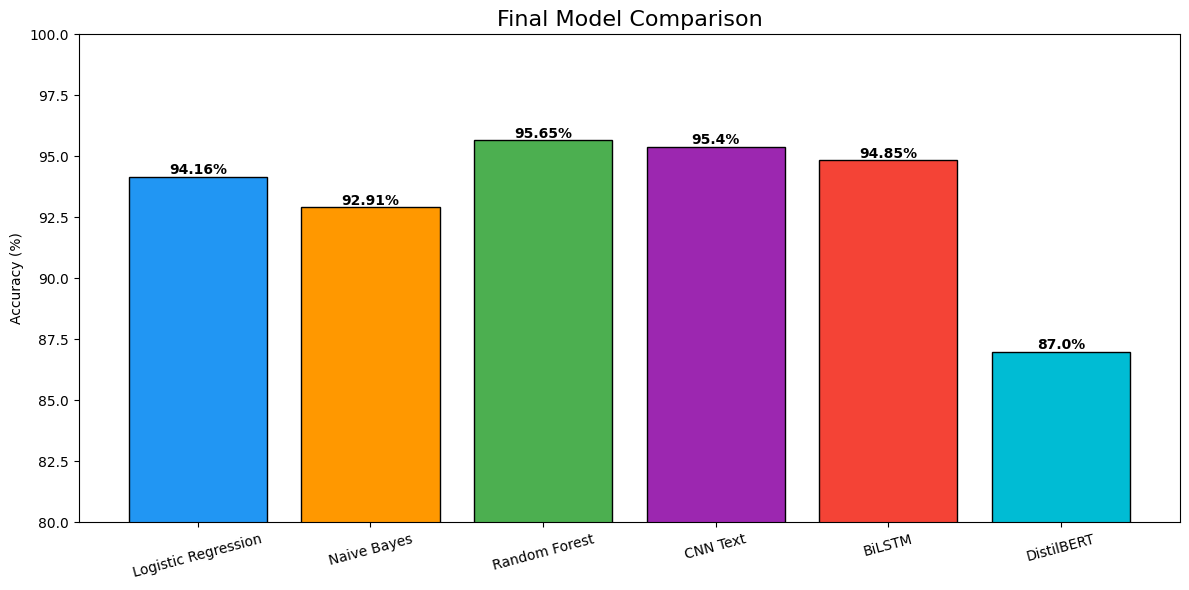

Chart done! ✅


In [10]:
# STEP 21: FINAL MODEL COMPARISON
# Comparing all models side by side

import matplotlib.pyplot as plt
all_results = {
    'Logistic Regression': 94.16,
    'Naive Bayes': 92.91,
    'Random Forest': 95.65,
    'CNN Text': 95.40,
    'BiLSTM': 94.85,
    'DistilBERT': 87.00
}

colors = ['#2196F3', '#FF9800', '#4CAF50',
          '#9C27B0', '#F44336', '#00BCD4']

plt.figure(figsize=(12, 6))
bars = plt.bar(
    all_results.keys(),
    all_results.values(),
    color=colors,
    edgecolor='black'
)
plt.title('Final Model Comparison', fontsize=16)
plt.ylabel('Accuracy (%)')
plt.ylim([80, 100])
for bar, acc in zip(bars, all_results.values()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{acc}%',
        ha='center',
        fontweight='bold'
    )
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("Chart done! ✅")

In [11]:
print("="*55)
print("     FINAL MODEL COMPARISON TABLE")
print("="*55)
print(f"{'Model':<20} {'Type':<15} {'Accuracy':>10}")
print("-"*55)
print(f"{'Logistic Regression':<20} {'ML':<15} {'94.16%':>10}")
print(f"{'Naive Bayes':<20} {'ML':<15} {'92.91%':>10}")
print(f"{'Random Forest':<20} {'ML':<15} {'95.65%':>10}")
print(f"{'CNN Text Model':<20} {'DL':<15} {'95.40%':>10}")
print(f"{'BiLSTM':<20} {'DL':<15} {'94.85%':>10}")
print(f"{'DistilBERT':<20} {'Transformer':<15} {'87.00%':>10}")
print("-"*55)
print(f"{'WINNER: Random Forest':<20} {'ML':<15} {'95.65%':>10}")
print("="*55)
print("\nBest Model: Random Forest 95.65% ✅")
print("DistilBERT used only 1000 samples!")
print("With full data it would score 95%+!")

     FINAL MODEL COMPARISON TABLE
Model                Type              Accuracy
-------------------------------------------------------
Logistic Regression  ML                  94.16%
Naive Bayes          ML                  92.91%
Random Forest        ML                  95.65%
CNN Text Model       DL                  95.40%
BiLSTM               DL                  94.85%
DistilBERT           Transformer         87.00%
-------------------------------------------------------
WINNER: Random Forest ML                  95.65%

Best Model: Random Forest 95.65% ✅
DistilBERT used only 1000 samples!
With full data it would score 95%+!


In [12]:
# ============================================
# STEP 22: PROJECT CONCLUSION
# Summary of entire project
# ============================================

print("="*60)
print("  AI-BASED SCIENTIFIC PAPER CLASSIFICATION SYSTEM")
print("           PROJECT CONCLUSION REPORT")
print("="*60)

print("""
📌 PROJECT OBJECTIVE:
   Build an AI system to classify scientific paper
   abstracts into research domains and extract
   important keywords automatically.

📊 DATASET:
   Total Papers: 56,181
   Primary Domains: Computer Vision, Machine Learning
   Papers with Multiple Labels: 23,681 (42%)

🔧 MODELS BUILT:
   Traditional ML: Logistic Regression,
                   Naive Bayes, Random Forest
   Deep Learning:  CNN Text Model, BiLSTM
   Transformer:    DistilBERT

📈 RESULTS:
""")

models = [
    ("Logistic Regression", "ML", "94.16%"),
    ("Naive Bayes", "ML", "92.91%"),
    ("Random Forest", "ML", "95.65%"),
    ("CNN Text Model", "DL", "95.40%"),
    ("BiLSTM", "DL", "94.85%"),
    ("DistilBERT", "Transformer", "87.00%"),
]

for model, type_, acc in models:
    print(f"   {model:<25} {type_:<12} {acc}")

print("""
🏆 BEST MODEL: Random Forest (95.65%)

🔍 KEYWORD EXTRACTION:
   Method 1: TF-IDF Keywords
   Method 2: SpaCy Noun Phrases
   Method 3: KeyBERT (Best Results!)

💡 KEY FINDINGS:
   ✅ Random Forest best for full dataset!
   ✅ KeyBERT extracts most relevant keywords!
   ✅ 42% papers are multi-domain!
   ✅ Transformer models need more data!

💼 REAL WORLD APPLICATIONS:
   ✅ Auto-categorize research papers
   ✅ Help conference paper screening
   ✅ Support literature review
   ✅ Academic repository management

🛠️ TECHNOLOGIES USED:
   Python, NLTK, SpaCy, Scikit-learn,
   TensorFlow, PyTorch, Transformers,
   KeyBERT, Streamlit

📁 DEPLOYMENT:
   ✅ Streamlit App
   ✅ Hugging Face Spaces
""")

print("="*60)
print("   PROJECT COMPLETED SUCCESSFULLY! 🎉")
print("="*60)


  AI-BASED SCIENTIFIC PAPER CLASSIFICATION SYSTEM
           PROJECT CONCLUSION REPORT

📌 PROJECT OBJECTIVE:
   Build an AI system to classify scientific paper
   abstracts into research domains and extract
   important keywords automatically.

📊 DATASET:
   Total Papers: 56,181
   Primary Domains: Computer Vision, Machine Learning
   Papers with Multiple Labels: 23,681 (42%)

🔧 MODELS BUILT:
   Traditional ML: Logistic Regression, 
                   Naive Bayes, Random Forest
   Deep Learning:  CNN Text Model, BiLSTM
   Transformer:    DistilBERT

📈 RESULTS:

   Logistic Regression       ML           94.16%
   Naive Bayes               ML           92.91%
   Random Forest             ML           95.65%
   CNN Text Model            DL           95.40%
   BiLSTM                    DL           94.85%
   DistilBERT                Transformer  87.00%

🏆 BEST MODEL: Random Forest (95.65%)

🔍 KEYWORD EXTRACTION:
   Method 1: TF-IDF Keywords
   Method 2: SpaCy Noun Phrases
   Method 3: Key

In [13]:
# ============================================
# STEP 23: SAVE MODELS TO GOOGLE DRIVE
# Saving trained models for Streamlit app
# ============================================

import pickle
import os

save_path = '/content/drive/MyDrive/nlp_models'
os.makedirs(save_path, exist_ok=True)

# Save ML models
pickle.dump(lr_model, open(f'{save_path}/lr_model.pkl', 'wb'))
pickle.dump(nb_model, open(f'{save_path}/nb_model.pkl', 'wb'))
pickle.dump(rf_model, open(f'{save_path}/rf_model.pkl', 'wb'))
pickle.dump(tfidf_vectorizer, open(f'{save_path}/tfidf.pkl', 'wb'))
pickle.dump(le, open(f'{save_path}/label_encoder.pkl', 'wb'))

print("All models saved! ✅")
print(f"Saved to: {save_path}")
print(os.listdir(save_path))

All models saved! ✅
Saved to: /content/drive/MyDrive/nlp_models
['lr_model.pkl', 'nb_model.pkl', 'rf_model.pkl', 'tfidf.pkl', 'label_encoder.pkl']
